In [1]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import sys
sys.path.append("../src")

from Autograd import Tensor
from Model import Linear,Sequential,Embedding,Flatten,Layernorm
from Loss import cross_entropy_loss
from Activation import ReLU
from Training import training
from Optimiser import SGD,Adam,Momentum,RMSProp,Adagrad,Adadelta


Machine learning models only work with numbers, not words. A common approach is to assign different words a unique ID randomly; from here we try to associate each ID with some vector in d dimensional space, where d can be chosen.

A naive approach could be to use hot-one vectors, but this has a major issue. If for example the word 'cat' was associated with the vector $e_1$, 'dog' $e_2$ and 'pizza' $e_3$ ($e_i$ is a standard basis vector). There is no notion that dog and cat are more closely linked than cat and pizza (same distance etc.), despite 2 of them being living animals and the other being an italian staple food.

A popular technique to overcome this is to use an embedding. The ID assigned to each word is used to find an associated vector in a lookup table. In the context of an MLP to predict the next word, we can think of the softmaxed output as a conditional probability distribution over the possible words given the context (previous words). The parameters can hence be learned by gradient descent using the same loss function as the other MLP parameters.

This approach can be applied to many contexts, not just words. For example, given a set of words, we could train an MLP to predict the next letter, where the letters of the alphabet are indexed 0 to 25.

In [6]:
chars=list("abcdefghijklmnopqrstuvwxyz.")
stoi={ch:i for i, ch in enumerate(chars)}
itos={i:ch for ch, i in stoi.items()}

In [7]:
df=pd.read_csv("../data/names.txt",header=None)
all=df[0].tolist()
random.shuffle(all)

n=int(len(all)*0.7)

words=all[:n]
remaining=all[n:]

X=[]
Y=[]
block_size=3
for word in words:
    context=[26]*block_size
    for ch in word+".":
        ix=stoi[ch]
        X.append(context)
        Y.append(ix)
        context=context[1:]+[ix]
X=Tensor(np.array(X,dtype=int))
Y=Tensor(np.array(Y,dtype=int))

test_ins=[]
test_out=[]

for word in remaining:
    context=[26]*block_size
    for ch in word+".":
        ix=stoi[ch]
        test_ins.append(context)
        test_out.append(ix)
        context=context[1:]+[ix]

test_ins=Tensor(np.array(test_ins,dtype=int))
test_out=Tensor(np.array(test_out,dtype=int))

The dictionaries above encode and decode the characters to an index and vice versa.

We then create a block_size window for each character in the name for all names. The list contains the IDs of the characters in the window. This list is then appended to X and Y stores the corresponding index of the actual character.

Each of these 'blocks' is used in the lookup table in the embedding to represent the 'block' in the form of a matrix, this is flattened as MLP expects vector inputs for a sample.

Increasing the dimensions of the representation of each token can increase how 'rich' the representation is, increasing complexity and potentially yielding better results.

In [8]:
model=Sequential([Embedding(27,10),Flatten(),Linear(10*block_size,32),Layernorm(32),ReLU(),Linear(32,27)])
loss_fn=cross_entropy_loss
optimiser=Adam(model.parameters(),0.005)
loss=training(X,model,Y,loss_fn,100,optimiser,128)

2.189425738278032


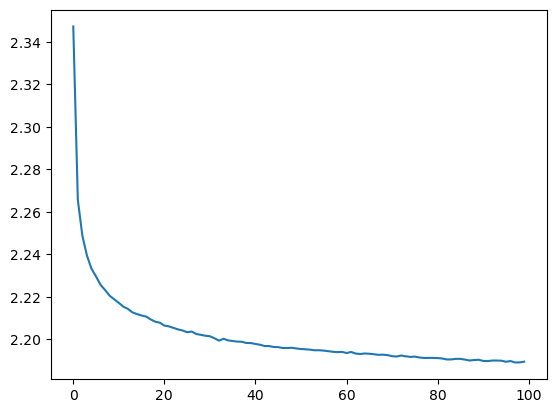

In [9]:
plt.plot(loss)
print(loss[-1])

We can see in the loss curve that the loss does decrease. Achieving a smaller loss may be possible using more epochs, different batch size as well as the use of different hyperparameters in Adam. From experimentation, the model's loss seems to plateu at around a loss of 2. This could be due to limitations in the complexity of the model.

In [10]:
test_logits=model.forward_prop(test_ins)
validation_loss=cross_entropy_loss(test_logits,test_out)
print(validation_loss.data)

2.202971840234161


Using the testing set we can see that the validation loss is 2.2, similar to the final training loss. So we have not overfit to the training data it seems. We can increase the performance by increasing model complexity (increased block size, embedding dimension and hidden layer dimensions) as well as using more epochs.

As the output is a probability distribution for the next character in this case we can use the decoding dictionary to convert the id predicted to the character. The id selected can either be done by picking the higheset probability (greedy pick) or random sampling over the given distribution.